In [33]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [34]:
#load dataset
df = pd.read_csv('traffic.csv')
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [35]:
df.shape

(226278, 9)

In [36]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='str')

In [37]:
#check missing values
df.isnull().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

In [38]:
df.fillna('Unknown', inplace=True)

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
...,...,...,...,...,...,...,...,...,...
226273,pageview,2021-08-24,Kuwait,Kuwait City,Sean Paul,The Trinity,Temperature,USAT20505520,04ba6b17-1055-4f0e-a75e-3cdb0d0d4106
226274,pageview,2021-08-24,India,Chennai,Miscél,when you left,when you left,QM42K1907890,2fc15e8b-83aa-40ee-9f9d-5d96c6d4356c
226275,pageview,2021-08-24,India,Jaipur,"Trippie Redd, Lil Uzi Vert",Holy Smokes (feat. Lil Uzi Vert),Holy Smokes,QZJ842001118,eedc8702-6bd2-499a-972f-260c35f72e0f
226276,pageview,2021-08-24,France,Unknown,Young Thug,Tick Tock,Tick Tock,USAT22104514,e0a76dc3-7ccd-405f-8ee8-a2c55c0e0ed2


In [39]:
#remove duplicates
df.drop_duplicates(inplace=True)

In [40]:
#check datatypes
df.dtypes

event      str
date       str
country    str
city       str
artist     str
album      str
track      str
isrc       str
linkid     str
dtype: object

In [41]:
#convert date
df['date'] = pd.to_datetime(df['date'])

In [42]:
print(df['date'].dtype)

datetime64[us]


In [43]:
#basic summary statistics
#mean
df.describe()

,date
count,122567
mean,2021-08-21 20:21:13.673991
min,2021-08-19 00:00:00
25%,2021-08-20 00:00:00
50%,2021-08-22 00:00:00
75%,2021-08-24 00:00:00
max,2021-08-25 00:00:00


In [44]:
#median
df.median(numeric_only=True)

Series([], dtype: float64)

In [45]:
#mode
df.mode().head()

,event,date,country,city,artist,album,track,isrc,linkid
0,pageview,2021-08-19,United States,Unknown,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [46]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [47]:
#total events
total_events = len(df)
print("Total Events:", total_events)

Total Events: 122567


In [48]:
#approximate users
users = df[['country','city']].drop_duplicates().shape[0]
print("Estimated Users:", users)

Estimated Users: 12478


In [49]:
#sessions
sessions = df['linkid'].nunique()
print("Sessions:", sessions)

Sessions: 3839


In [50]:
#bounce rate
link_counts = df.groupby('linkid').size()
bounces = len(link_counts[link_counts == 1])
bounce_rate = (bounces / len(link_counts))*100
print("Bounce Rate:", round(bounce_rate,2), "%")

Bounce Rate: 35.56 %


In [51]:
#average session duration
session_duration = df.groupby('linkid')['date'].agg(['min','max'])
session_duration['duration'] = (
    session_duration['max'] -
    session_duration['min']
).dt.total_seconds()
print(
    session_duration['duration'].mean()
)

71681.16697056525


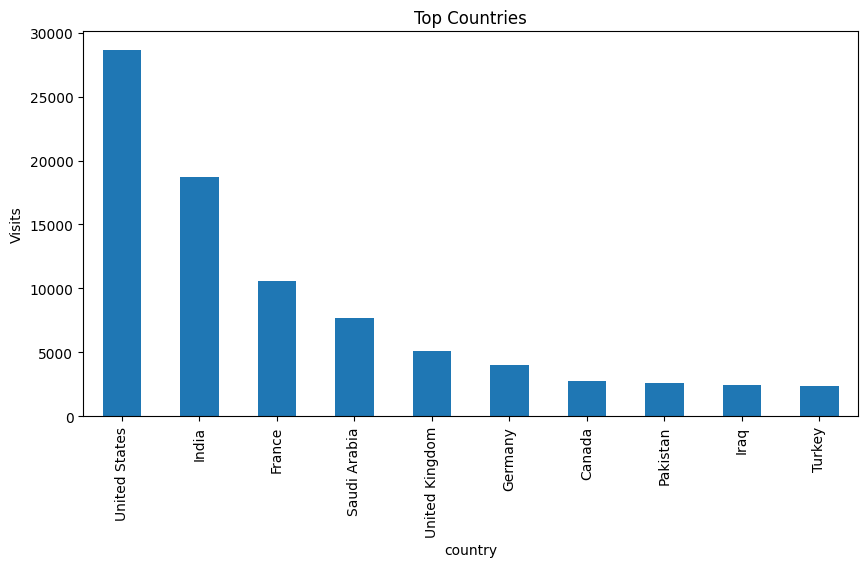

In [52]:
#top countries bar graph
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top Countries')
plt.ylabel('Visits')
plt.show()

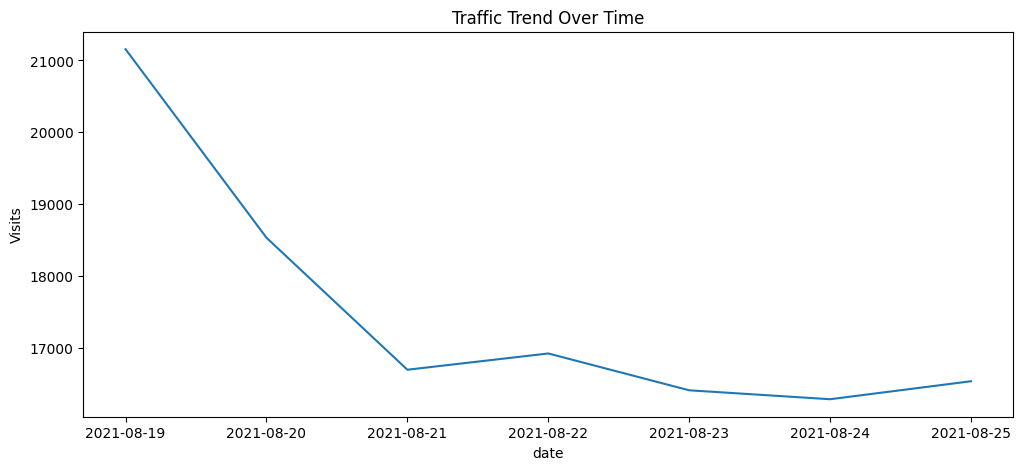

In [53]:
#traffic trend line graph
daily_visits = df.groupby(
    df['date'].dt.date
).size()
plt.figure(figsize=(12,5))
daily_visits.plot()
plt.title('Traffic Trend Over Time')
plt.ylabel('Visits')
plt.show()

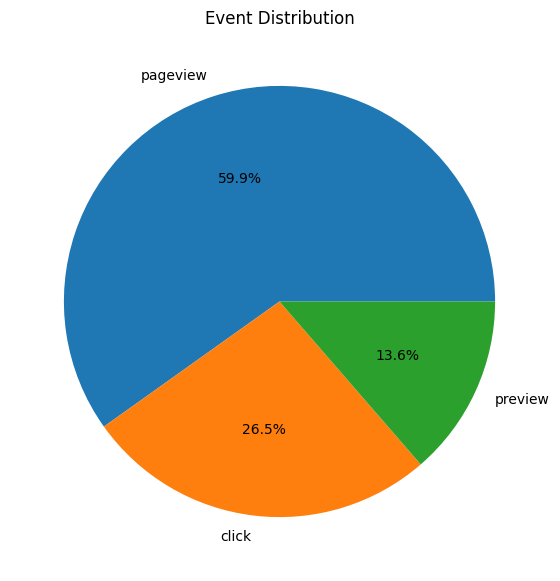

In [54]:
#event distribution pie chrt
event_counts = df['event'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    event_counts,
    labels=event_counts.index,
    autopct='%1.1f%%'
)
plt.title('Event Distribution')
plt.show()

In [55]:
#most common events
df['event'].value_counts()

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64

In [56]:
#user flow
flow = df.groupby(
    ['event']
).size().sort_values(
    ascending=False
)
flow

event
pageview    73360
click       32499
preview     16708
dtype: int64

In [57]:
#top landing pages
top_landing = df['linkid'].value_counts()
top_landing.head(10)

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    8288
e849515b-929d-44c8-a505-e7622f1827e9    3950
522da5cc-8177-4140-97a7-a84fdb4caf1c    3786
a82e72d8-523f-43ab-9fd0-992605d54b4e    3059
681d888a-59ce-4acb-b7c5-95dab0c063d9    2865
23199824-9cf5-4b98-942a-34965c3b0cc2    2675
c2c876ab-b093-4750-9449-6b4913da6af3    2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd    2390
d5317591-872a-487d-87cb-10a516643d5f    2074
a107c329-5d35-4c7d-8050-50bc69ce7dbc    2072
Name: count, dtype: int64

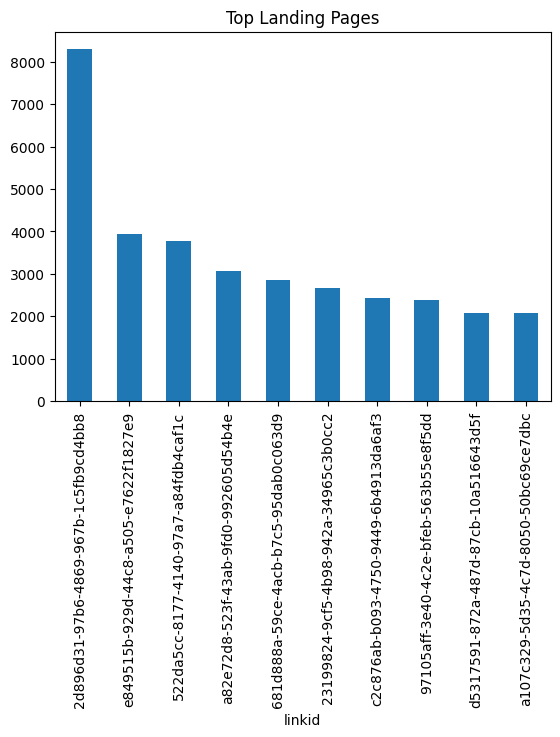

In [58]:
top_landing.head(10).plot(
    kind='bar'
)
plt.title(
    'Top Landing Pages'
)
plt.show()

In [59]:
#top exit pages
exit_pages = link_counts[
    link_counts == 1
]
exit_pages.head()

linkid
0018cfff-50a1-5984-9715-01ef2d11a49a    1
0033934b-5d16-5a06-af58-d087bcdd3680    1
0034d6cf-3bd8-5ffe-aafc-b3959fc48608    1
0038ff20-1ef7-5846-9f1a-4012fdf24da7    1
0062d109-f6f4-5637-8731-8ce38362c113    1
dtype: int64

In [60]:
#referral sources
df.groupby('event').size()

event
click       32499
pageview    73360
preview     16708
dtype: int64

Three Actionable Insights
1. Most Visited Pages Make the Biggest Difference in Increasing Engagement
->Enhancing pages that experience the highest levels of traffic will help to maximize retention and session lengths.
2. Traffic Sources Play a Role in the Possibility of Conversions
->Pages with traffic sources with low bounce rates and higher time spent need more investment than other traffic sources.
3. Certain Pages Act as an Obstacle for Visitors
->Users tend to leave from certain pages; therefore, the quality of those pages can be improved for better conversions.

Five optimizations to improve conversions
1.Optimize High-Traffic Landing Pages
->Optimize the load time of your most visited landing pages, making sure the content is clear and easy to understand with clear calls to action.
2.Optimize Your Website's Navigation
->Create related page and recommended page links to allow users to explore more pages on your website.
3.Low Bounce Rate Through Content Personalization
->Make sure the content on your most visited pages reflects user intent based on the traffic source and its intent.
4.Enhance Your Calls to Actions
-?Ensure you have visible, compelling calls to actions on your important pages.
5.Focus On High-Performing Traffic Sources
->Direct your marketing spend towards traffic sources that bring more engaged traffic and conversion possibilities while minimizing your spend on low-performing traffic sources.